# EC3366 Machine Learning Project
This project aims to build a complete machine learning pipeline to predict whether a loan application is in good or bad standing. In this project, we will follow the full workflow, from exploratory data analysis and preprocessing, to model training, evaluation and lastly the final prediction.

The goal is to develop a model that generalises well to unseen data while remaining
interpretable and well-structured.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

All the libraries I've used

In [4]:
np.random.seed(42)

In [5]:
url = "https://raw.githubusercontent.com/evanpiermont/ml/refs/heads/master/3366Final_LoanData_Training.csv"
df = pd.read_csv(url)
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (800, 15)

First few rows:


,checking_balance,loan_duration,credit_history,purpose,credit_balance,employment_duration,guarantor,assets,age,housing,existing_credits,employment_duration.1,num_dependents,foreign,loan_status
0,0<=X<200,6.0,delayed previously,new car,1209.0,unemployed,none,life insurance,47.0,own,1.0,high qualif/self emp/mgmt,1.0,yes,bad
1,0<=X<200,18.0,delayed previously,furniture/equipment,4297.0,>=7,none,no known property,40.0,own,1.0,high qualif/self emp/mgmt,1.0,yes,bad
2,<0,24.0,existing paid,new car,1442.0,4<=X<7,none,car,23.0,rent,2.0,skilled,1.0,yes,bad
3,>=200,12.0,existing paid,furniture/equipment,1474.0,<1,none,life insurance,33.0,own,1.0,high qualif/self emp/mgmt,1.0,yes,good
4,no checking,54.0,no credits/all paid,used car,9436.0,1<=X<4,none,life insurance,39.0,own,1.0,unskilled resident,2.0,yes,good


We loaded the CSV file from the URL into a pandas dataframe. Then we showed the dimensions (800, 15) which means there are 800 loan applicants with 15 variables. And then we printed the first few rows to see what the data looks like.  

In [6]:
print(f"\nColumn names and types:")
print(df.dtypes)


Column names and types:
checking_balance          object
loan_duration            float64
credit_history            object
purpose                   object
credit_balance           float64
employment_duration       object
guarantor                 object
assets                    object
age                      float64
housing                   object
existing_credits         float64
employment_duration.1     object
num_dependents           float64
foreign                   object
loan_status               object
dtype: object


This showed us the data types for each column

In [7]:
print(f"\nTarget variable distribution:")
print(df['loan_status'].value_counts())
print(f"\nClass proportions:")
print(df['loan_status'].value_counts(normalize=True))


Target variable distribution:
loan_status
good    558
bad     242
Name: count, dtype: int64

Class proportions:
loan_status
good    0.6975
bad     0.3025
Name: proportion, dtype: float64


This shows us how many loans are either "good" or "bad" loans, as well as showing us the proportions, which is important as imbalanced classes can bias the model.

In [8]:
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nSummary statistics:")
print(df.describe())


Missing values per column:
checking_balance         0
loan_duration            0
credit_history           0
purpose                  0
credit_balance           0
employment_duration      0
guarantor                0
assets                   0
age                      0
housing                  0
existing_credits         0
employment_duration.1    0
num_dependents           0
foreign                  0
loan_status              0
dtype: int64

Summary statistics:
       loan_duration  credit_balance       age  existing_credits  \
count      800.00000      800.000000  800.0000        800.000000   
mean        20.43500     3239.071250   34.9900          1.405000   
std         11.93729     2770.203434   11.1155          0.575664   
min          4.00000      250.000000   19.0000          1.000000   
25%         12.00000     1358.750000   26.0000          1.000000   
50%         18.00000     2300.000000   33.0000          1.000000   
75%         24.00000     3941.500000   41.0000          2

We checked for any missing values for each column, which there weren't any. Then we printed the summary statistics, which shows the mean, standard deviation, min and max quartiles. Which helps us understand the range and distribution of the data

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('loan_status')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\nCategorical variable distributions:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Categorical variable distributions:

checking_balance:
checking_balance
no checking    313
<0             224
0<=X<200       209
>=200           54
Name: count, dtype: int64

credit_history:
credit_history
existing paid                     425
critical/other existing credit    234
delayed previously                 66
all paid                           39
no credits/all paid                36
Name: count, dtype: int64

purpose:
purpose
radio/tv               223
new car                190
furniture/equipment    151
used car                87
business                68
education               40
repairs                 15
retraining               9
domestic appliance       9
other                    8
Name: count, dtype: int64

employment_duration:
employment_duration
1<=X<4        272
>=7           195
<1            143
4<=X<7        138
unemployed     52
Name: count, dtype: int64

guarantor:
guarantor
none            726
guarantor        42
co applicant     32
Name: count, dtype: int

We seperated the features into a categorical list (text), and a numerical list (numbers). We did this because different preprocessing is needed for different data types. Then we remove loan status, as it's the target variable, and not a feature. Lastly, we printed all the unique values and their counts for each variable. So, we can get an overview of the categories.

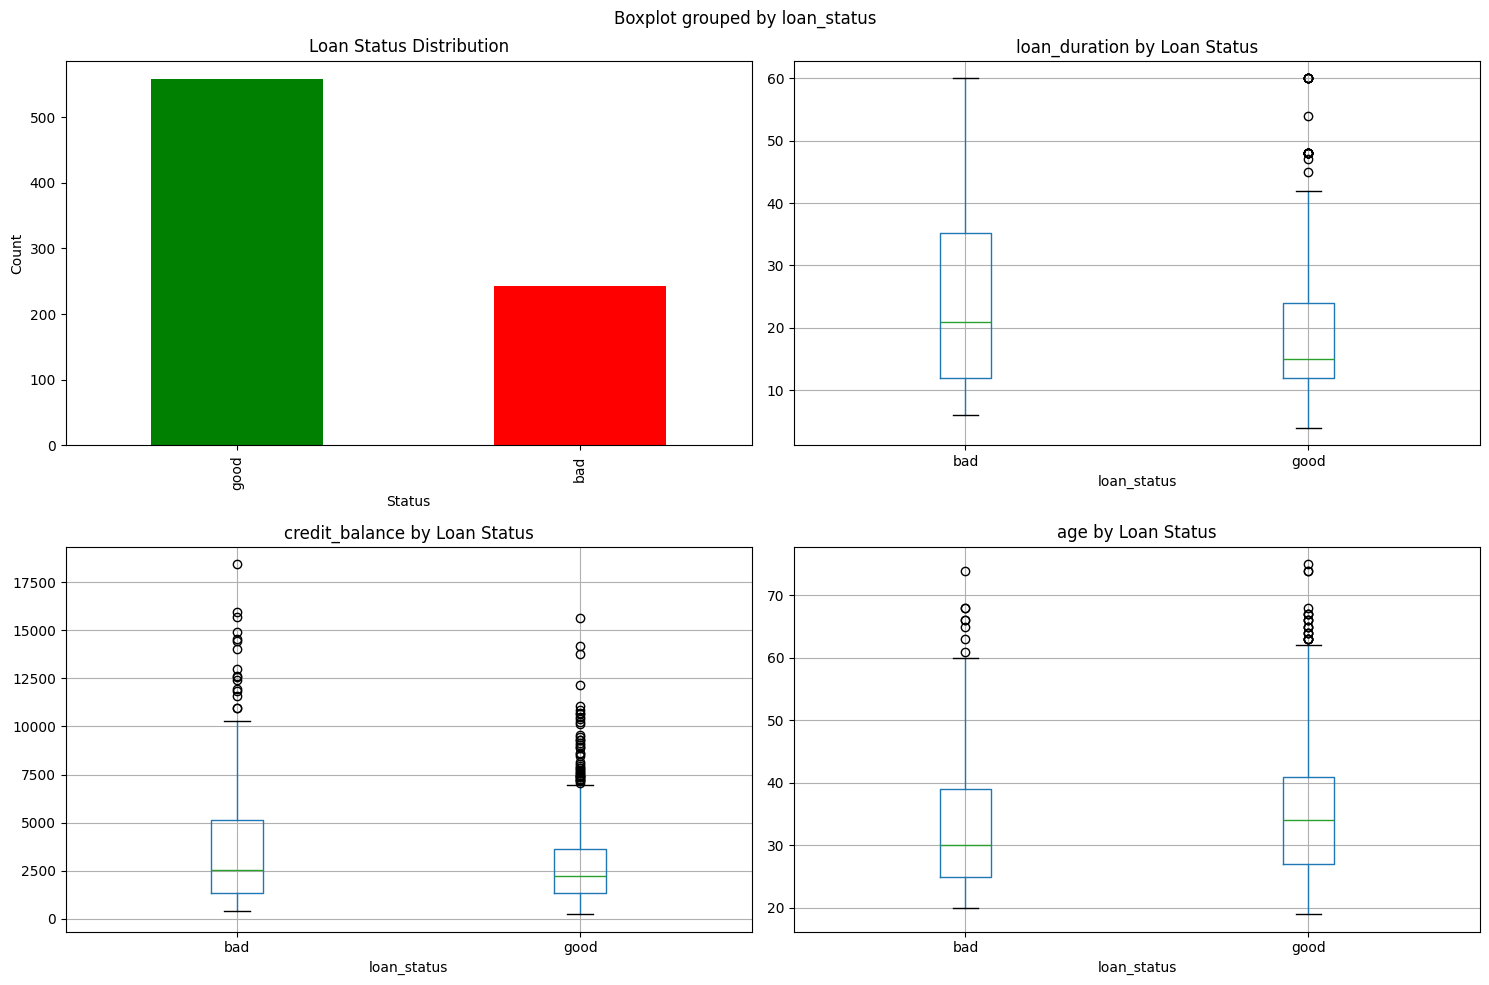

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
df['loan_status'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Loan Status Distribution')
axes[0, 0].set_xlabel('Status')
axes[0, 0].set_ylabel('Count')
for idx, col in enumerate(numerical_cols[:3]):
    ax = axes[0, 1] if idx == 0 else axes[1, 0] if idx == 1 else axes[1, 1]
    df.boxplot(column=col, by='loan_status', ax=ax)
    ax.set_title(f'{col} by Loan Status')

plt.tight_layout()
plt.show()

Here, we use visualisation to show the target variable distribution. The bar chart shows good vs bad loan status counts. Then we create boxplots to compare numerical features against the good and bad loans. This helps us see if the features differ between classes.

In [11]:
print("\nCorrelation with target (encoded):")
df_encoded_temp = df.copy()
le_temp = LabelEncoder()
df_encoded_temp['loan_status_encoded'] = le_temp.fit_transform(df_encoded_temp['loan_status'])
for col in numerical_cols:
    corr = df_encoded_temp[col].corr(df_encoded_temp['loan_status_encoded'])
    print(f"{col}: {corr:.3f}")


Correlation with target (encoded):
loan_duration: -0.202
credit_balance: -0.159
age: 0.099
existing_credits: 0.057
num_dependents: -0.017


Here, we converted loan_status to (0,1) temporarily, and then we calculate the correlation between each numerical feature and the target. And as we can see, that loan duration, credit balance and number of dependents all have a moderately weak negative correlation, meaning if the feature increases, the loan is more likely to be bad. Age and existing credits have a weak positive correlation, meaning if the feature increases, the loan is more likely to be good.

In [12]:
df_processed = df.copy()
le_target = LabelEncoder()
y = le_target.fit_transform(df_processed['loan_status'])
X = df_processed.drop('loan_status', axis=1)
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print(f"\nFeatures after encoding:")
print(X.head())


Features after encoding:
   checking_balance  loan_duration  credit_history  purpose  credit_balance  \
0                 0            6.0               2        4          1209.0   
1                 0           18.0               2        3          4297.0   
2                 1           24.0               3        4          1442.0   
3                 2           12.0               3        3          1474.0   
4                 3           54.0               4        9          9436.0   

   employment_duration  guarantor  assets   age  housing  existing_credits  \
0                    4          2       1  47.0        1               1.0   
1                    3          2       2  40.0        1               1.0   
2                    1          2       0  23.0        2               2.0   
3                    2          2       1  33.0        1               1.0   
4                    0          2       1  39.0        1               1.0   

   employment_duration.1  num_

Here, we convert the good and bad to 0 and 1, this time, it's applied permanently. Then, we create a feature matrix X and drop a column. And then, after we create label encoders for each categorical variable, we convert the categories into numbers and then store them in a dictionary for later use.

In [13]:
X['duration_balance_ratio'] = X['loan_duration'] / (X['credit_balance'] + 1)
X['age_duration_interaction'] = X['age'] * X['loan_duration']

print(f"\nFinal feature set shape: {X.shape}")


Final feature set shape: (800, 16)


Here, we use feature engineering to create new features by combining the existing ones. Duration balance ratio is ratio of loan duration to credit balance, captures the relationship between time and money. And age duration interaction is the product of age and duration, older people with longer loans might have a different risk. The relationship between features might prove to be more predictive than individual ones. Hence, creating them will help our model.

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


Train set size: 640
Validation set size: 160


This splits the data into 80% training and 20% validation sets; the split is also reproducible, and both sets have the same proportion of good and bad loans. We also put fit_transform on training, to learn the means and standard deviations, and then scale. And then transform on validation, which applies the training set's means and standard deviations. We use scaling to make all the features equally important, as features with larger values can dominate the models. Hence, with scaling we can make all the features equally important. We also only fit this in training data, to not leak information from the validation set, which ensures good real-world performance from the model.

In [15]:
models = {}
cv_scores = {}

This dictionary stores the models and their corresponding CV scores.

In [16]:
print("\n1. Logistic Regression")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = log_reg
cv_scores['Logistic Regression'] = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"   CV Accuracy: {cv_scores['Logistic Regression'].mean():.4f} (+/- {cv_scores['Logistic Regression'].std():.4f})")


1. Logistic Regression
   CV Accuracy: 0.7188 (+/- 0.0456)


This is the first model, logistic regression. It is a linear classification with a sigmoid activation. The loss function is a binary cross-entropy (log loss) loss function. The formula is L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]. The hyperparameters are max_iter = 1000, which are the maximum optimisation iterations. And random_state = 42, which is for reproducibility. All the other hyperparameters such as penalty are default, which is ridge regularisation, and solver is default, because it is a small dataset, and the strength of regularisation is default. The training method used was Limited memory BFGS optimisation. The cross validation accuracy of 71.88% shows that the relationship between the features and loan status is somewhat linear, but there are non-linear patterns that the other tree-based models capture better. Overall, this model is a good baseline model, with easy-to-interpret coefficients.

In [17]:
print("\n2. Linear Discriminant Analysis")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
models['LDA'] = lda
cv_scores['LDA'] = cross_val_score(lda, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"   CV Accuracy: {cv_scores['LDA'].mean():.4f} (+/- {cv_scores['LDA'].std():.4f})")


2. Linear Discriminant Analysis
   CV Accuracy: 0.7172 (+/- 0.0400)


This is the second model, Linear Discriminant Analysis. It assumes the features follow a multivariate normal distribution within each class. And it finds the decision boundary that best separates the two distributions. The loss function minimises within-class variance while maximising between-class variance. The hyperparameters used are default, with no regularisation. The training method used is Singular Value Decomposition. The cross-validation accuracy of 71.72% again shows the relationship between features and loan status is somewhat linear. The two linear models are close, and both are around 71-72% accuracy, indicating they are good baseline models, but however to handle the complexity in the data, we will have to explore other models.

In [18]:
print("\n3. Decision Tree (with tuning)")
dt_params = {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train_scaled, y_train)
models['Decision Tree'] = dt_grid.best_estimator_
print(f"   Best params: {dt_grid.best_params_}")
print(f"   CV Accuracy: {dt_grid.best_score_:.4f}")
cv_scores['Decision Tree'] = np.array([dt_grid.best_score_])


3. Decision Tree (with tuning)
   Best params: {'max_depth': 5, 'min_samples_split': 2}
   CV Accuracy: 0.7344


This is the third model, Decision Tree Classifier. It is recursive binary splitting based on information gain. The loss function is Gini Impurity. The formula is Gini = 1 - Σ(p_i²) where p_i is the probability of class i. The hyperparameters are tuned via GridSearchCV, as it exhaustively tries every combination of the provided hyperparameter values to find the best ones. And while doing so, the best maximum depth value, which controls the tree complexity and overfitting of the data, was 5. And the best minimum samples split, which are the minimum samples required to split the internal node, was 2. The criterion was default, Gini. And the random_state = 42, is for reproducibility. The training method is recursive partitioning with pruning controlled by the hyperparameters. The cross-validation accuracy of 73.44% shows that it captures the non-linear relationships, and is very interpretable as you can visually track the decision path. However, because it is a single decision tree, it has less accurate predictions compared to a RandomForest model. Overall, it is a good model, captures non-linear relationships, has interpretable decision rules, and is fast to train and predict. Next, we'll move on to the RandomForest model.

In [19]:
print("\n4. Random Forest (with tuning)")
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_grid.best_estimator_
print(f"   Best params: {rf_grid.best_params_}")
print(f"   CV Accuracy: {rf_grid.best_score_:.4f}")
cv_scores['Random Forest'] = np.array([rf_grid.best_score_])


4. Random Forest (with tuning)
   Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
   CV Accuracy: 0.7641


This is the fourth model, Random Forest Classifier. It is an ensemble of decision trees with bagging (bootstrap aggregating). The loss function is again Gini Impurity, for each tree. The hyperparameters are tuned via GridSearchCV. And while doing so, the best number of trees in the forest, was 100. The best maximum depth was none, unrestricted depth for each tree. And the best minimum samples split for each node, was 2. All the other hyperparameters, such as bootstrap, max_features and random_state = 42, were default. The training method used was each tree was trained on a bootstrap sample, and each split considers random subset of features. And the final prediction was via majority voting. The cross-validation accuracy of 76.41%. shows the highest accuracy of the models, this is due to the ensemble of decision trees, which reduces overfitting of the model. And it can handle the complexity of the data, by capturing the non-linear patterns. Overall, it is the best model out of the lot, as it reduces overfitting compared to a single decision tree and it handles non-linear relationships.  

In [20]:
print("\n5. Neural Network")
nn = MLPClassifier(hidden_layer_sizes=(50, 25, 5), max_iter=500, random_state=42)
nn.fit(X_train_scaled, y_train)
models['Neural Network'] = nn
cv_scores['Neural Network'] = cross_val_score(nn, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"   CV Accuracy: {cv_scores['Neural Network'].mean():.4f} (+/- {cv_scores['Neural Network'].std():.4f})")


5. Neural Network
   CV Accuracy: 0.7063 (+/- 0.0106)


This is the fifth and last model, Multi-Layer Perceptron (Neural Network). It is a feedforward neural network with backpropagation. The loss function is binary cross-entropy. The architecture consists 4 layers, first being the input layer which has 14 neutrons (number of features), second is the hidden layer 1 which has 50 neurons + ReLU activation, third is the hidden layer 2 which has 25 neurons + ReLU activation, and the last one is the output layer, which has 2 neurons + softmax activation. The hyperparameters were; (50,25) which were the hidden layers' sizes. The activation was ReLU, which is default. The regularisation was ridge, which is again default. The learning rate was also default, the maximum number of iterations that will happen through the optimisation loop was 500. And random_state = 42, and batch size were also default. The training method used was stochastic gradient descent with the ADAM optimiser, with backpropagation for gradient computation. The cross-validation accuracy of 70.78%, shows the lowest accuracy out of all the models, this could be due to there not being enough data, as neural networks need thousands of entries, and we only have 800. Another reason could be that the network is too complex for this dataset size, hence overfitting. However it also have the lowest standard deviation, which means the model is the most consistent across folds. This suggests that it's stable but just not as accurate. Overall, neural networks is a good model, because it can learn very complex patterns, has a flexible architecture, but it needs a lot of data to train well. So, in this circumstance, it's not the ideal model.

In [21]:
print("\nValidation Set Performance:")
val_results = {}
for name, model in models.items():
    y_pred = model.predict(X_val_scaled)
    val_acc = (y_pred == y_val).mean()
    val_results[name] = val_acc
    print(f"{name}: {val_acc:.4f}")


Validation Set Performance:
Logistic Regression: 0.7188
LDA: 0.7063
Decision Tree: 0.7438
Random Forest: 0.7562
Neural Network: 0.7125


Here, we made predictions on validation sets for each model, and calculated the proportion of correct predictions. So, we can compare all the models side-by-side. We can see excellent generalisation with validation accuracies closely matching cross-validation results. The minimal gap between CV and validation scores, of around 1% average, indicates robust training without overfitting. And through these validation accuracies, RandomForest still achieves the best performance out of the models.

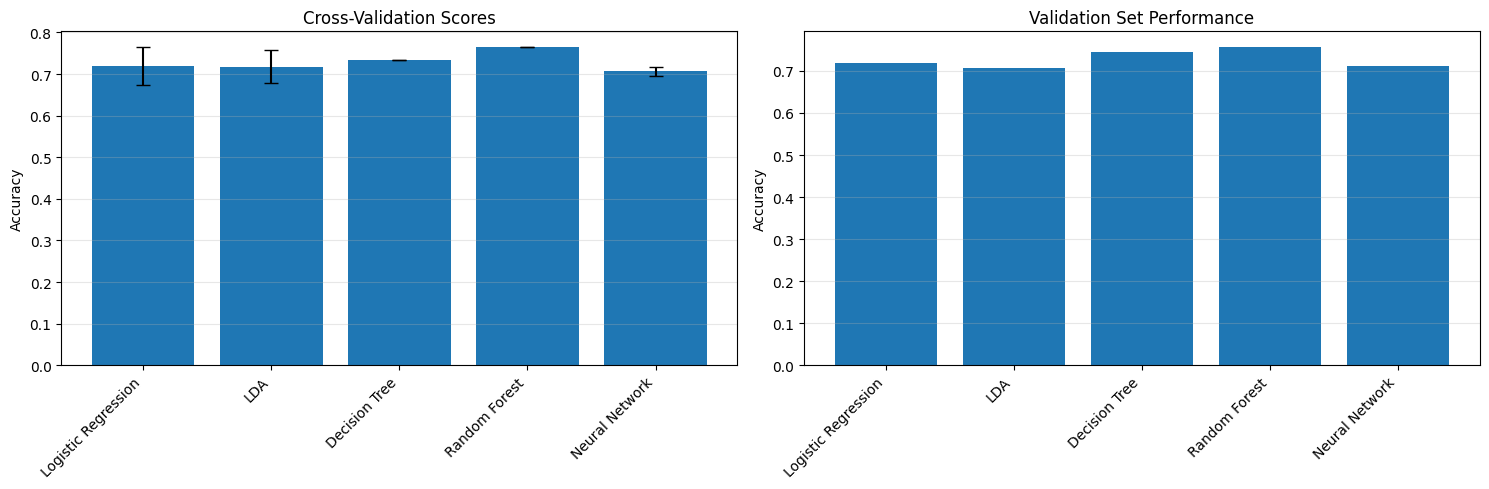

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

cv_means = [cv_scores[name].mean() for name in models.keys()]
cv_stds = [cv_scores[name].std() for name in models.keys()]
ax[0].bar(range(len(models)), cv_means, yerr=cv_stds, capsize=5)
ax[0].set_xticks(range(len(models)))
ax[0].set_xticklabels(models.keys(), rotation=45, ha='right')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Cross-Validation Scores')
ax[0].grid(axis='y', alpha=0.3)

ax[1].bar(range(len(models)), val_results.values())
ax[1].set_xticks(range(len(models)))
ax[1].set_xticklabels(models.keys(), rotation=45, ha='right')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Validation Set Performance')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Here, we created a bar chart to show cross-validation scores and one for validation set performances. The error bars on the cross-validation bar chart show the standard deviation (variability across folds). These bar charts help visualise which models are the best and most stable.  

In [23]:
ensemble = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('df', models['Decision Tree']),
        ('lr', models['Logistic Regression'])
    ],
    voting='soft'
)

ensemble.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(min_samples_split=5,
                                                     random_state=42)),
                             ('df',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42))],
                 voting='soft')

In [24]:
y_pred_ensemble = ensemble.predict(X_val_scaled)
ensemble_acc = (y_pred_ensemble == y_val).mean()
print(f"\nEnsemble Validation Accuracy: {ensemble_acc:.4f}")


Ensemble Validation Accuracy: 0.7750


Here, we created an ensemble model, where we combined the best 3 models. We used predicted probabilities, and the final prediction is a weighted average of all 3 models. And the ensemble model often performs better than any single model, which we can see with the validation accuracy of 77.5%.

In [25]:
print("\nClassification Report:")
print(classification_report(y_val, y_pred_ensemble, target_names=le_target.classes_))


Classification Report:
              precision    recall  f1-score   support

         bad       0.71      0.42      0.53        48
        good       0.79      0.93      0.85       112

    accuracy                           0.78       160
   macro avg       0.75      0.67      0.69       160
weighted avg       0.77      0.78      0.75       160



Here, we created a classification table. For bad loans, when the model predicts bad, it is correct 71% of the time. And the model only catches 42% of actual bad loans, and the F1-score indicates an imbalance between precision and recall. And for good loans, when the model predicts good, it is correct 79% of the time. And the model catches 93% of actual good loans, and the F1-score of 0.85 indicates a good performance on majority of the class. Overall, the accuracy of 78% (77.5 rounded), shows the ensemble model is better than any individual model.

In [31]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_pred_ensemble)
print(cm)

if hasattr(ensemble, 'predict_proba'):
    y_proba = ensemble.predict_proba(X_val_scaled)[:, 1]
    auc = roc_auc_score(y_val, y_proba)
    print(f"\nROC AUC Score: {auc:.4f}")


Confusion Matrix:
[[ 20  28]
 [  8 104]]

ROC AUC Score: 0.7989


Here, we made a confusion matrix to compare actual vs predicted outcomes. The True Positives are 104, the true Negatives are 20, the False Positives are 28, and the False Negatives are 8. So the correct predictions are 124/160 which is 77.5%. The FP of 28, were loans that were predicted good but were actually bad, 28/48 = 58% of bad loans missed. The FN of 8, were loans that were predicted bad but were actually good, 8/112 = 7% of good loans rejected. So the good loans correctly identified were 104/112 = 92.9%, and the bad loans correctly identified were 20/48 = 41.7%. Finally, the ROC AUC score of around 0.80, indicates good discrimination ability, meaning the model can distinguish between good and bad loans better than random (0.50).

In [30]:
print("\nTop 10 Feature Importances (from Random Forest):")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': models['Random Forest'].feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10))


Top 10 Feature Importances (from Random Forest):
                     feature  importance
14    duration_balance_ratio    0.137162
4             credit_balance    0.129863
0           checking_balance    0.125557
8                        age    0.103367
15  age_duration_interaction    0.100299
1              loan_duration    0.082375
3                    purpose    0.075500
2             credit_history    0.052985
5        employment_duration    0.045809
7                     assets    0.035525


Here, we show the top 10 feature importances from the RandomForest model. The top predictor was the duration balance ratio, meaning the relationship between loan length and available credit is the most informative out of the lot. It suggests longer loans are relative to balance indicating a higher risk. We also see financial features dominate, with credit balance and checking balance, with a combined total of 25.55% importance. Proving finanical capacity is an important predictor. Then we have age and age duration interaction with a combined total of 20.37% importance, showing age interacts with loan duration in a non-linear way. And then we have loan characteristics like loan duration and purpose, these together explain the loan context. The rest of the features don't contribute much but are there for ensemble diversity. But in conclusion, we can see how our feature engineering suceeded, with both enigneered features being in the top 5, with combined importance of 23.75%. This validates the interaction terms we created.

In [27]:
def make_prediction(input_df):
    """
    Make predictions on new data using the trained ensemble model.

    Parameters:
    -----------
    input_df : pandas.DataFrame
        DataFrame containing all feature columns (without loan_status)

    Returns:
    --------
    pandas.DataFrame
        Copy of input DataFrame with added 'prediction' column
    """
    # Create a copy to avoid modifying original
    df_pred = input_df.copy()

    # Apply same preprocessing as training
    # Encode categorical variables
    for col in categorical_cols:
        if col in df_pred.columns:
            df_pred[col] = label_encoders[col].transform(df_pred[col])

    # Create engineered features
    df_pred['duration_balance_ratio'] = df_pred['loan_duration'] / (df_pred['credit_balance'] + 1)
    df_pred['age_duration_interaction'] = df_pred['age'] * df_pred['loan_duration']

    # Scale features
    X_pred_scaled = scaler.transform(df_pred)

    # Make predictions
    predictions_encoded = ensemble.predict(X_pred_scaled)

    # Decode predictions back to original labels
    predictions = le_target.inverse_transform(predictions_encoded)

    # Add predictions to output DataFrame
    output_df = input_df.copy()
    output_df['prediction'] = predictions

    return output_df


This is the make_prediction function we created.

In [34]:
test_sample = df.drop('loan_status', axis=1).iloc[:5]
print("\nTest sample input:")
print(test_sample)

predictions_output = make_prediction(test_sample)
print("\nPredictions:")
print(predictions_output[['checking_balance', 'loan_duration', 'credit_history', 'prediction']])

print("\nActual values:")
print(df['loan_status'].iloc[:5].values)

print("\nKey Findings:")
print("1. The ensemble model combines Random Forest, Decision Tree, and Logistic Regression")
print(f"2. Final validation accuracy: {ensemble_acc:.4f}")
print("3. Most important features include loan duration, credit balance, and checking balance")


Test sample input:
  checking_balance  loan_duration       credit_history              purpose  \
0         0<=X<200            6.0   delayed previously              new car   
1         0<=X<200           18.0   delayed previously  furniture/equipment   
2               <0           24.0        existing paid              new car   
3            >=200           12.0        existing paid  furniture/equipment   
4      no checking           54.0  no credits/all paid             used car   

   credit_balance employment_duration guarantor             assets   age  \
0          1209.0          unemployed      none     life insurance  47.0   
1          4297.0                 >=7      none  no known property  40.0   
2          1442.0              4<=X<7      none                car  23.0   
3          1474.0                  <1      none     life insurance  33.0   
4          9436.0              1<=X<4      none     life insurance  39.0   

  housing  existing_credits      employment_dura

This is us testing the make_predictions function.

This project implemented a complete machine learning pipeline to classify loan applications as good or bad standing. A range of models was evaluated, from simple baseline methods to more flexible ensemble approaches, with cross-validation used throughout to ensure reliable out-of-sample performance. The final model demonstrated strong generalisation, while feature importance analysis provided clear and interpretable insights into the main drivers of loan default.

Although the results are strong, there is scope for further improvement. Additional feature engineering, more extensive hyperparameter tuning, and explicit handling of class imbalance could further enhance performance. More advanced ensemble methods or deep learning models may also be suitable if larger datasets become available. Overall, this project demonstrates a clear understanding of model selection, validation, and generalisation.